In [7]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
pth_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/'

### Get all the data

In [10]:
colors = ['#1f77b4','#2ca02c','#9467bd']
colors2 = ['darksalmon','coral','olive']
scatters = ['.','+','^','v']

df_dils_prmse = pd.read_csv(f'{pth_table}/prmse_recalc_linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150_unitchange_Gtunitfix.csv')
df_dils = pd.read_csv(f'{pth_table}linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150_unitchange_Gtunitfix.csv')
#df_dils_prmse = pd.read_csv('tables/prmse_recalc_linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150.csv')
#df_dils = pd.read_csv(f'{pth_table}linear_dynamic_ice_loss_sensitivity_from_cumBMB_tmin2150.csv')

regions = df_dils.columns[4:].values.tolist()
regions = ['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']
regions_all= regions.copy()
regions1 = regions[1:]
regions_all1=regions1.copy()

experiments = np.unique(df_dils["Experiment"])
df_exp = df_dils[df_dils['Experiment']== experiments[0]].reset_index(drop=True)
models = df_exp.Model.values

df_best = df_exp.copy()
df_best['mean-error']=1e15
df_best = df_best.drop(df_best.columns[0:2],axis=1)
#df_best = df_best.drop(df_best.columns[1],axis=1)
df_best = df_best.drop(df_best.columns[1:11],axis=1)
for region in regions:
    df_best[f'dils_{region}']=0
    df_best[f'dils_std_{region}']=0
    df_best[f'dils_min_{region}']=0
    df_best[f'dils_max_{region}']=0
    df_best['parameterization']=''
    df_best['calving']=''
    df_best['initialisation']=''
    df_best['resolution']=''
    df_best['shelfarea']=''
    df_best['meltonpartial']=''
    df_best['icefront']=''

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3' 

In [11]:
df_info

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,0,DC,ISSM,ctrlAE,ctrl,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
2,2,DC,ISSM,expAE03,HadGEM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
3,3,DC,ISSM,expAE04,CESM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
4,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,VUW,PISM,ctrlAE,ctrl,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
211,211,VUW,PISM,expAE02,CCSM4,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
212,212,VUW,PISM,expAE03,HadGEM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
213,213,VUW,PISM,expAE04,CESM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR


In [12]:
# initialisation
initialisation={'DC_ISSM':'DA', 'DOE_MALI_4km':'DA+', 'DOE_MALI_8km_Ant95':'DA+', 'DOE_MALI_8km_AntMean':'DA+',\
                'IGE_ElmerIce':'DA', 'ILTS_SICOPOLIS':'SP+', 'IMAU_UFEMISM1':'SP+', 'IMAU_UFEMISM2':'SP+', \
                'IMAU_UFEMISM3':'SP+', 'IMAU_UFEMISM4':'SP+', 'LSCE_GRISLI2':'SP+', 'LSCE_GRISLI':'SP+', \
                'NCAR_CISM1':'SP+', 'NCAR_CISM2':'SP+', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':'SP+', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM4-MAR364-ERA-t1-local':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM2-MAR364-ERA-t1':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-JRA-t1':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1':'SP+', 'PIK_PISM':'SP', 'UCM_Yelmo':'SP+', 'UCSD_ISSM':'DA', \
                'ULB_fETISh-KoriBU1':'DA*', 'ULB_fETISh-KoriBU2':'DA*', 'UNN_Ua':'DA', 'UTAS_ElmerIce':'DA',\
                'VUB_AISMPALEO':'SP', 'VUW_PISM1':'SP', 'VUW_PISM1_s1':'SP', 'VUW_PISM1_s2':'SP', 'VUW_PISM1_s3':'SP',\
                'VUW_PISM1_s4':'SP','VUW_PISM2':'SP', 'VUW_PISM2_s1':'SP', 'VUW_PISM2_s2':'SP', 'VUW_PISM2_s3':'SP', 'VUW_PISM2_s4':'SP'}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'initialisation'] = initialisation[Mod]

In [13]:
# calving group
calving_group={'DC_ISSM':2, 'DOE_MALI_4km':2, 'DOE_MALI_8km_Ant95':2, 'DOE_MALI_8km_AntMean':2,\
                'IGE_ElmerIce':2, 'ILTS_SICOPOLIS':2, 'IMAU_UFEMISM1':2, 'IMAU_UFEMISM2':2, \
                'IMAU_UFEMISM3':2, 'IMAU_UFEMISM4':2, 'LSCE_GRISLI2':1, 'LSCE_GRISLI':1, \
                'NCAR_CISM1':2, 'NCAR_CISM2':2, 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':2, 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM3-MAR364-ERA-t1-local':2, 'NORCE_CISM4-MAR364-ERA-t1-local':2, \
                'NORCE_CISM5-MAR364-ERA-t1-local':2, 'NORCE_CISM2-MAR364-ERA-t1':2, \
                'NORCE_CISM3-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-JRA-t1':2, \
                'NORCE_CISM5-MAR364-ERA-t1':2, 'PIK_PISM':1, 'UCM_Yelmo':1, 'UCSD_ISSM':3, \
                'ULB_fETISh-KoriBU1':3, 'ULB_fETISh-KoriBU2':2, 'UNN_Ua':2, 'UTAS_ElmerIce':2,\
                'VUB_AISMPALEO':2, 'VUW_PISM1':1, 'VUW_PISM1_s1':1, 'VUW_PISM1_s2':1, 'VUW_PISM1_s3':1,\
                'VUW_PISM1_s4':1,'VUW_PISM2':1, 'VUW_PISM2_s1':1, 'VUW_PISM2_s2':1, 'VUW_PISM2_s3':1, 'VUW_PISM2_s4':1}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'calving'] = calving_group[Mod]

In [14]:
# melt on partial
mop_group={'DC_ISSM':'SG', 'DOE_MALI_4km':'FC', 'DOE_MALI_8km_Ant95':'FC', 'DOE_MALI_8km_AntMean':'FC',\
           'IGE_ElmerIce':'no', 'ILTS_SICOPOLIS':'FC', 'IMAU_UFEMISM1':'FC', 'IMAU_UFEMISM2':'FC', \
           'IMAU_UFEMISM3':'FC', 'IMAU_UFEMISM4':'FC', 'LSCE_GRISLI2':'no', 'LSCE_GRISLI':'FC', \
           'NCAR_CISM1':'SG', 'NCAR_CISM2':'SG', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':'FC', \
           'NORCE_CISM4-MAR364-ERA-t1-nonlocal':'FC', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':'FC', \
           'NORCE_CISM3-MAR364-ERA-t1-local':'FC', 'NORCE_CISM4-MAR364-ERA-t1-local':'FC', \
           'NORCE_CISM5-MAR364-ERA-t1-local':'FC', 'NORCE_CISM2-MAR364-ERA-t1':'FC', \
           'NORCE_CISM3-MAR364-ERA-t1':'FC', 'NORCE_CISM4-MAR364-ERA-t1':'FC', 'NORCE_CISM4-MAR364-JRA-t1':'FC', \
           'NORCE_CISM5-MAR364-ERA-t1':'FC', 'PIK_PISM':'FC', 'UCM_Yelmo':'SG', 'UCSD_ISSM':'SG', \
           'ULB_fETISh-KoriBU1':'no', 'ULB_fETISh-KoriBU2':'no', 'UNN_Ua':'no', 'UTAS_ElmerIce':'SG',\
           'VUB_AISMPALEO':'n/a', 'VUW_PISM1':'no', 'VUW_PISM1_s1':'no', 'VUW_PISM1_s2':'no', 'VUW_PISM1_s3':'no',\
           'VUW_PISM1_s4':'no','VUW_PISM2':'yes', 'VUW_PISM2_s1':'yes', 'VUW_PISM2_s2':'yes', 'VUW_PISM2_s3':'yes', 'VUW_PISM2_s4':'yes'}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'meltonpartial'] = mop_group[Mod]

In [15]:
clname = df_best.columns
i_clname = np.arange(0,clname.size)

for l,df in enumerate(df_best):
    
    for i,Mod in enumerate(models):
        #iterate though model names
        best = 1e15
        dfmodel = df_dils[df_dils['Model']== Mod].copy()
    
        for j,region in enumerate(regions):
            mdn = np.nanmean(dfmodel[f'{region}'].values).copy() #get mean from all 4 exp for each region
            std = np.nanstd(dfmodel[f'{region}'].values).copy() #get std from all 4 exp for each region
            df_best.loc[i, f'dils_{region}'] = np.nanmean(dfmodel[f'{region}'].values).copy()
            df_best.loc[i, f'dils_std_{region}'] = np.nanstd(dfmodel[f'{region}'].values).copy()
            df_best.loc[i, f'dils_min_{region}'] = np.nanmin(dfmodel[f'{region}'].values).copy()
            df_best.loc[i, f'dils_max_{region}'] = np.nanmax(dfmodel[f'{region}'].values).copy()

        if df_dils.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
            nmname = renamer[df_dils.iloc[i].Model]
        else:
            nmname = Mod
        
        df_info_model = df_info[df_info['fileID']==nmname]
        df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        
        # set melt parameterisation
        meltparam = df_info_model_exp['Melt parameterisation'].values[0]
        df_best.loc[i, 'parameterization'] = meltparam

        # set ice front
        icefront = df_info_model_exp['ice front'].values[0]
        df_best.loc[i, 'icefront'] = icefront
    
        # set resolution
        resolution = df_info_model_exp['Resolution'].values[0]
        df_best.loc[i, 'resolution'] = resolution
        
regions_all.append('mean-error')


/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_1531/4042771583.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.13920153962547743' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_best.loc[i, f'dils_{region}'] = np.nanmean(dfmodel[f'{region}'].values).copy()
/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_1531/4042771583.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.03664151487303748' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_best.loc[i, f'dils_std_{region}'] = np.nanstd(dfmodel[f'{region}'].values).copy()
/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_1531/4042771583.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future versio

In [16]:
df_output = df_best.copy()
df_output = df_output.drop(columns=['dils_std_AIS',
                                    'dils_std_Amundsen',
                                    'dils_std_Ross',
                                    'dils_std_FilchnerRonne',
                                    'dils_std_Aurora',
                                    'dils_std_Wilkes'])
new_order = ['Model', 'calving', 'initialisation','resolution', 'meltonpartial','icefront',
             'dils_AIS', 'dils_min_AIS', 'dils_max_AIS',
             'dils_Amundsen', 'dils_min_Amundsen', 'dils_max_Amundsen',
             'dils_Ross', 'dils_min_Ross', 'dils_max_Ross',
             'dils_FilchnerRonne', 'dils_min_FilchnerRonne', 'dils_max_FilchnerRonne',
             'dils_Aurora','dils_min_Aurora', 'dils_max_Aurora',
             'dils_Wilkes', 'dils_min_Wilkes','dils_max_Wilkes']
df_output = df_output[new_order]

df_output.to_csv(f'{pth_table}/best_dils_per_model_v3_unitchange_Gtunitfix.csv')

In [17]:
df_output

,Model,calving,initialisation,resolution,meltonpartial,icefront,dils_AIS,dils_min_AIS,dils_max_AIS,dils_Amundsen,...,dils_max_Ross,dils_FilchnerRonne,dils_min_FilchnerRonne,dils_max_FilchnerRonne,dils_Aurora,dils_min_Aurora,dils_max_Aurora,dils_Wilkes,dils_min_Wilkes,dils_max_Wilkes
0,DC_ISSM,2,DA,4km,SG,MH,0.139202,0.084437,0.186464,0.230672,...,0.289350,0.225896,0.190427,0.305836,0.160476,0.137236,0.194806,0.275010,0.186216,0.365767
1,DOE_MALI_4km,2,DA+,4km,FC,RO,0.539856,0.403630,0.651688,0.587587,...,0.708535,0.459150,0.332870,0.676987,0.521899,0.448875,0.593079,0.654557,0.594721,0.686058
2,DOE_MALI_8km_Ant95,2,DA+,8km,FC,RO,0.535333,0.459921,0.633979,0.366748,...,0.888363,0.561681,0.448808,0.761512,0.662929,0.528583,0.833126,0.755348,0.658566,0.832581
3,DOE_MALI_8km_AntMean,2,DA+,8km,FC,RO,0.519709,0.439775,0.609567,0.405466,...,0.902589,0.527032,0.399591,0.729831,0.597266,0.502343,0.708308,0.742029,0.670840,0.848854
4,IGE_ElmerIce,2,DA,1km,no,Fix,0.076694,0.022917,0.107247,0.208557,...,0.130232,0.118594,0.106446,0.134246,0.060359,-0.006818,0.113457,0.373866,0.357118,0.394378
5,ILTS_SICOPOLIS,2,SP+,8km,FC,MH,0.609922,0.499309,0.718761,0.711370,...,0.713550,0.480342,0.413958,0.576629,0.593752,0.478827,0.718442,0.625559,0.302437,0.832045
6,IMAU_UFEMISM1,2,SP+,32km,FC,Fix,2.356588,0.812217,4.025508,2.590867,...,7.377036,4.085152,0.531605,8.374722,13.615738,-0.391099,32.297789,-0.561217,-2.244870,0.000000
7,IMAU_UFEMISM2,2,SP+,32km,FC,Fix,2.611821,1.105948,4.649660,0.000000,...,5.691460,4.275231,0.715436,9.712004,-33.201393,-92.307697,-0.804593,-0.776168,-3.104670,0.000000
8,IMAU_UFEMISM3,2,SP+,16km,FC,Fix,2.146105,1.292535,3.496777,7.772858,...,3.512557,2.450950,0.802884,5.258994,2.923404,-0.318579,4.864287,-26.794978,-102.295255,0.042116
9,IMAU_UFEMISM4,2,SP+,16km,FC,Fix,2.225853,1.305627,3.710895,79.374407,...,3.242107,5.048371,0.841683,15.436943,3.129304,2.153495,4.345093,-15.467220,-62.414461,1.570448


## Plot the main figure

#### Exclude some dodgy models

In [18]:
df_best_new = df_best.copy()
removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4']
#removekeys = ['VUB_AISMPALEO', 'VUW_PISM1_s1']
for i,key in enumerate(removekeys):
    df_best_new = df_best_new.drop(np.where(df_best_new.Model.values==key)[0][0]).reset_index(drop=True)

### The paper figure

In [1]:
index = np.argsort(df_best_new[f'dils_AIS'].values)
index = index[::-1]
tappend = '_tmin2150'

marker_key = 'initialisation'

marker_field_u = np.unique(df_best_new[marker_key])

marker_u = ['*','s','P','v','^','p']
dic_marker = {}
for i,key in enumerate(marker_field_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best_new.Model.values != 'VUW_PISM2_s1'

for key in df_best_new[marker_key][index]:
    markers.append(dic_marker[key])

for key in df_best_new[marker_key][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
#colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
colors = ['black','#882255', '#44AA99', '#117733', '#332288', '#DDCC77']

for i,region in enumerate(regions[::-1]):
    y = df_best_new[f'dils_{region}'].values[index]
    y_err_lower = df_best_new[f'dils_min_{region}'].values[index]
    y_err_upper = df_best_new[f'dils_max_{region}'].values[index]
    xall = np.arange(len(index)) * 8 + 5 - 0.5 * i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=50)
        else:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=25)
        plt.plot([x,x], [yl,yu], color=colors[::-1][i], alpha=0.2)
        
ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best_new['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('Dynamic ice loss sensitivity factor') ##TODO: Check units

# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=marker_field_u[i]) 
                  for i in range(len(marker_field_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]

# Combine marker and color legends into one
combined_handles = color_handles + marker_handles
combined_labels = regions + marker_field_u.tolist()

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Region & Initialisation", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

# Save the figure with tight bounding box
f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_AIS_{marker_key}{tappend}_Gtunitfix.pdf', bbox_inches='tight')
f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_AIS_{marker_key}{tappend}_Gtunitfix.jpeg', bbox_inches='tight')

NameError: name 'np' is not defined

### The supp figures? Regional + process-based

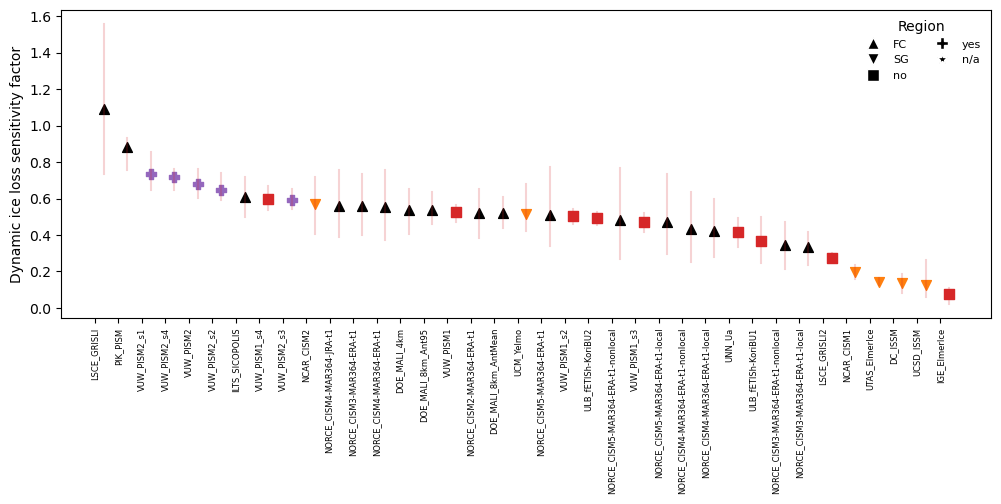

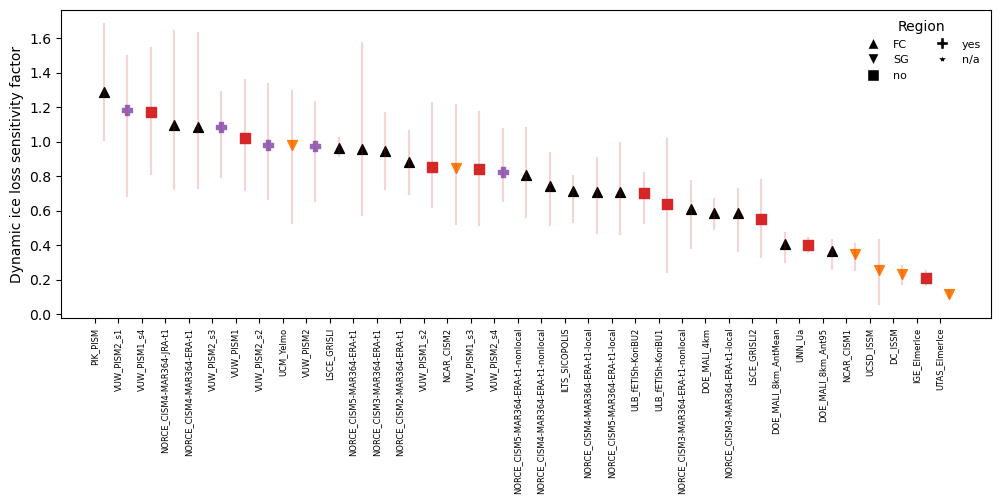

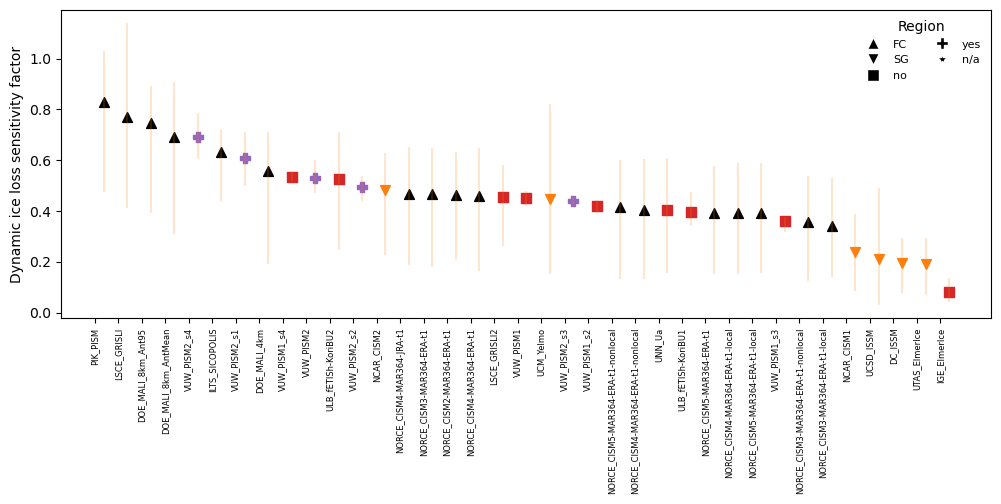

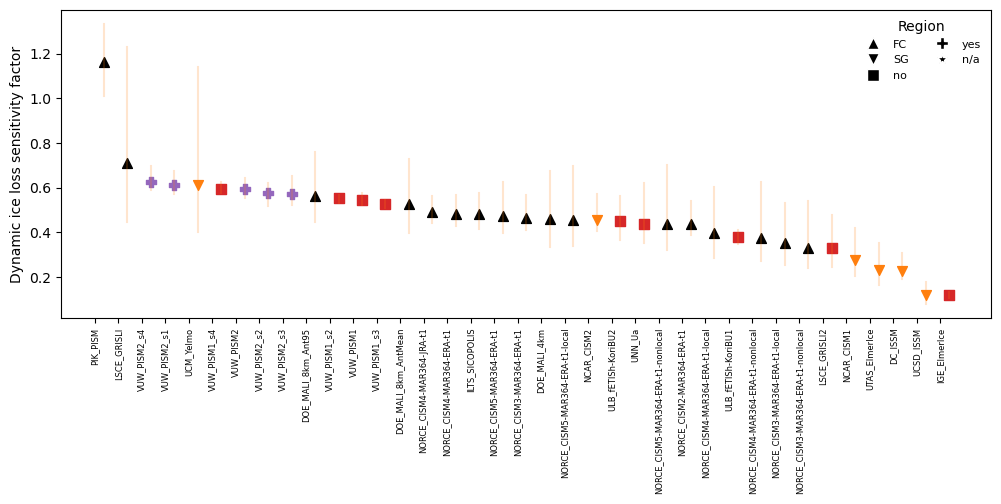

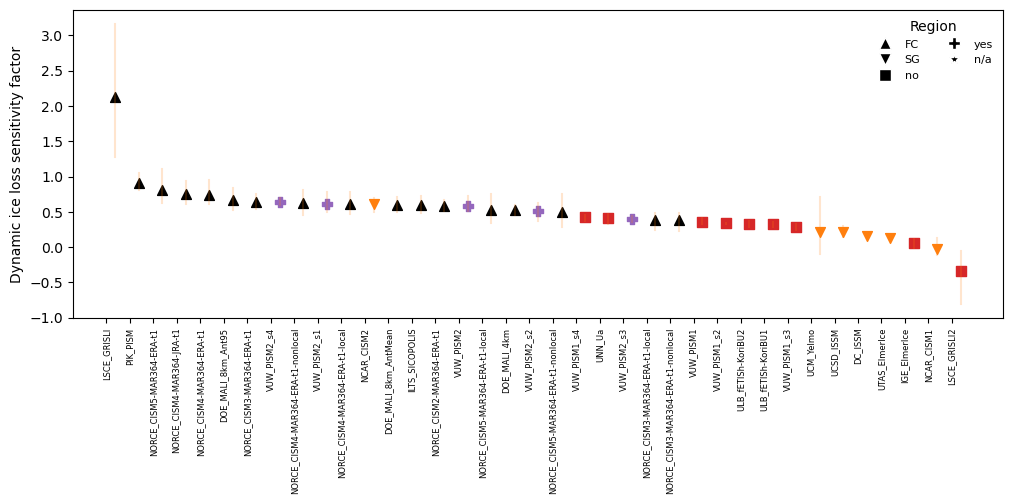

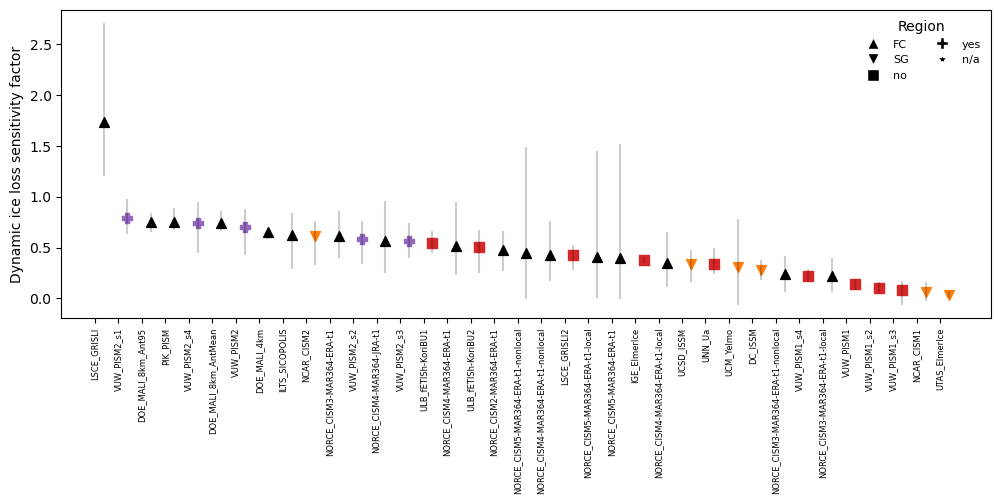

In [22]:
for ss,region in enumerate(regions):
    index = np.argsort(df_best_new[f'dils_{region}'].values)
    index = index[::-1]
    tappend = '_tmin2150'
    
    #marker_key = 'icefront'
    #marker_key = 'initialisation'
    #marker_key = 'parameterization'
    #marker_key = 'resolution'
    marker_key = 'meltonpartial'

    color = ['black','#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    marker_field_u = np.unique(df_best_new[marker_key])
    if marker_key == 'icefront':
        marker_field_u = np.array(['MH', 'RO', 'Fix', 'StR', 'VM', 'Div'])
    
    if marker_key == 'resolution':
        size_u = [4, 20, 50, 100, 170]
        size_field_u = np.array(['1km', '4km', '8km', '16km', '32km'])
        marker_u = ['o', 'o', 'o', 'o', 'o']
        marker_field_u = np.array(['1km', '4km', '8km', '16km', '32km'])
    elif marker_key == 'meltonpartial':
        marker_field_u = np.array(['FC', 'SG', 'no', 'yes', 'n/a'])
        color = ['black','#ff7f0e', '#d62728', '#9467bd', '#2ca02c']
        marker_u = ['^','v','s','P','*']
    else:
        #marker_u = ['*','s','P','v','^','p']
        marker_u = ['^','v','*','s','P','p']
    dic_marker = {}
    dic_color = {}
    for i,key in enumerate(marker_field_u):
        dic_marker[key]= marker_u[i]
        dic_color[key]= color[i]
    markers = []
    colors = []
    marker_nomodel=[]
    color_nomodel = []
    msk = df_best_new.Model.values != 'VUW_PISM2_s1'
    
    for key in df_best_new[marker_key][index]:
        markers.append(dic_marker[key])
        colors.append(dic_color[key])
    
    for key in df_best_new[marker_key][msk]:
        marker_nomodel.append(dic_marker[key])
        color_nomodel.append(dic_color[key])

    if marker_key == 'resolution':
        dic_size = {}
        for i,key in enumerate(size_field_u):
            dic_size[key]= size_u[i]
        sizes = []
        size_nomodel=[]
        msk = df_best_new.Model.values != 'VUW_PISM2_s1'
        
        for key in df_best_new[marker_key]:
            sizes.append(dic_size[key])
        
        for key in df_best_new[marker_key][msk]:
            size_nomodel.append(dic_size[key])
    
    f,ax = plt.subplots(1,1,figsize =(12,4))
    
    #for i,region in enumerate(regions[::-1]):
    y = df_best_new[f'dils_{region}'].values[index]
    y_err_lower = df_best_new[f'dils_min_{region}'].values[index]
    y_err_upper = df_best_new[f'dils_max_{region}'].values[index]
    xall = np.arange(len(index)) * 8 + 5 - 0.5 * i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if marker_key == 'resolution':
            plt.scatter(x, ym, marker=markers[j], color=colors[j], s=sizes[index[j]])
        else:
            plt.scatter(x, ym, marker=markers[j], color=colors[j], s=50)
        plt.plot([x,x], [yl,yu], color=colors[::-1][ss], alpha=0.2)
        
    ax.set_xticks(np.arange(len(index))*8)
    ax.set_xticklabels(df_best_new['Model'].values[index], rotation = 90,fontsize =6)
    ax.set_ylabel('Dynamic ice loss sensitivity factor') ##TODO: Check units
    
    # Legend for markers
    if marker_key == 'resolution':
        size_u = [4,7,10,12,14]
        marker_handles = [plt.Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor='k', markersize=size) 
                                     for size in size_u]
    else:
        marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                                     markerfacecolor='k', markersize=8, 
                                     label=marker_field_u[i]) 
                          for i in range(len(marker_field_u))]
    
    # combined_handles = marker_handles
    # combined_labels = marker_field_u.tolist()
    
    # Add the combined legend
    ax.legend(handles=marker_handles, labels=marker_field_u.tolist(), title="Region", 
              loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)
    
    # Save the figure with tight bounding box
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region_{region}_{marker_key}{tappend}_unitchange.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/dils-regions/dils_region_{region}_{marker_key}{tappend}_unitchange.jpeg', bbox_inches='tight')

In [23]:
marker_field_u

array(['FC', 'SG', 'no', 'yes', 'n/a'], dtype='<U3')

In [24]:
AISsort = np.sort(df_best_new['dils_AIS'])
Amundsensort = np.sort(df_best_new['dils_Amundsen'])
Wilkessort = np.sort(df_best_new['dils_Wilkes'])
Aurorasort = np.sort(df_best_new['dils_Aurora'])
AISdiff = AISsort.max() / AISsort.min()
Amundsendiff = AISsort.max() / Amundsensort.min()
Wilkesdiff = Wilkessort.max() / Wilkessort.min()
Auroradiff = Aurorasort.max() / Aurorasort.min()


In [25]:
Wilkesdiff

46.26942993369404

In [26]:
AISdiff

14.223758280963644

In [27]:
Amundsendiff

9.089302364643581

In [28]:
Auroradiff

-6.401309469007485

In [29]:
df_best_new = df_best.copy()
models = df_dils_prmse['Model'].unique()
for i,mod in enumerate(models):
    dfmodel = df_dils_prmse[df_dils_prmse['Model']==mod]
    mean_error = np.nanmean(dfmodel['AIS'])
    df_best_new.loc[df_best_new['Model'] == mod, 'mean-error'] = mean_error

In [30]:
regions

['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']

In [31]:
index = np.argsort(df_best_new['mean-error'].values)

for j,region in enumerate(regions):
    f,ax = plt.subplots(1,1,figsize =(12,4))
    ax2 = ax.twinx()
    ax.scatter(np.arange(len(index)),df_best_new['mean-error'].values[index],color = 'black')
    # for i in range(len(index)):
    #     ax.annotate(df_best['parameterization'].values[index][i],(i,df_best['mean-error'].values[index][i]),rotation = 90)
    
    ax.set_xticks(np.arange(len(index)))
    ax.set_xticklabels(df_best_new['Model'].values[index], rotation = 90)
    ax.set_ylabel('predictive mean  relative error (%)')
    ax2.scatter(np.arange(len(index)),df_best_new[f'dils_{region}'].values[index], color = 'red',alpha =  0.5)
     
    ax2.set_ylabel('Dynamic ice loss sensitivity',color = 'red')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_prmse_{region}{tappend}_unitchange_Gtunitfix.pdf', bbox_inches='tight')
    f.savefig(f'/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_prmse_{region}{tappend}_unitchange_Gtunitfix.jpeg', bbox_inches='tight')
    plt.close()